# Robust Classification Under Noisy Labels (Flowers Dataset)

**CS 484 Final Project**

Kevin Cui kevin.cui@uwaterloo.ca | Jessica Gao jessica.gao@uwaterloo.ca

## Abstract

Label noise is one of the most pressing problems in real-world machine learning datasets: crowdsourced annotation platforms, web-scraped image collections, and domain-inexperienced annotators all introduce mislabelled examples at rates that routinely exceed 20-30%. Standard cross-entropy training is known to overfit noisy labels through a process called loss memorisation, in which deep models, or even linear classifiers, assign progressively higher confidence to incorrect labels during the later stages of training, degrading generalisation performance on clean held-out data. Addressing this problem is very important for real-world models, as deploying a model trained on noisy annotations without robustness mechanisms can silently underperform on production data in ways that are difficult to detect without a clean validation set and reflect a very widespread constraint.

This project aims to benchmark different model methods against different types of noise to uncover which methods work best in different scenarios. To do this, the experiment implements and benchmarks six noise-robust classification methods on the Kaggle Flowers Recognition dataset. A frozen DINO ViT-S/16 encoder extracts 384-dimensional embeddings for all 4,317 images. Using a fixed pretrained backbone avoids confounding architecture learning with label noise effects and allows all methods to be evaluated as linear classifiers over the same feature representations. The six methods: Baseline Cross-Entropy, Label Smoothing, Symmetric Cross-Entropy (SCE), Generalised Cross-Entropy (GCE), GMM-based sample reweighting (GMMReweight), and Confident Learning (CL), are evaluated across three synthetic noise types (uniform, asymmetric, instance-dependent), six noise rates (0-50%), and three random seeds, yielding 324 training runs. In addition, a custom Flask annotation tool was also developed to collect 500 human-annotated labels which were collected under timed conditions of 3 seconds per image, producing a real-noise dataset used in two further experiments.

## Team contributions
* Jessica Gao jessica.gao@uwaterloo.ca
    * built the logistic regression, GMM reweight, and label smoothing methods
    * developed the training and testing pipeline to run experiments
    * wrote report sections for code libraries, dataset, prediction methods, and final plots
* Kevin Cui kevin.cui@uwaterloo.ca
    * developed the human annotation tool
    * implemented different synthetic noise methods
    * built the confident learning, GCE, and SCE methods
    * wrote report sections for abstract, noise models, and results 

## Code libraries
| Library | What it was used for | Installation instructions |
|---|---|---|
| torch | ML framework for training/evaluating classifiers | `pip install torch` |
| torchvision | image preprocessing transforms and feature extraction | `pip install torchvision` |
| numpy | feature matrix operations, noise injection, and result aggregation | `pip install numpy` |
| matplotlib | plotting and figure generation to visualize results | `pip install matplotlib` |
| flask | web app backend for the human annotation tool | `pip install flask` |
| scikit-learn | GMM fitting (GMM Reweight) and cross-validation (Confident Learning) | `pip install scikit-learn` |

---
## Setup & imports

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys, json, time, warnings
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
warnings.filterwarnings('ignore')

ROOT = Path().resolve()
MYLIBS = ROOT / 'mylibs'

if str(MYLIBS) not in sys.path:
    sys.path.insert(0, str(MYLIBS))

print(f"Project root: {ROOT}")
print(f"mylibs/: {MYLIBS}")
print(f"Python: {sys.version.split()[0]}")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()} "
      f"({'GPU: ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'})")

%matplotlib inline

Project root: C:\Users\Kevin Cui\Desktop\School\Winter 2026\CS 484\Final Project\Noisy-Label-Classifier
mylibs/: C:\Users\Kevin Cui\Desktop\School\Winter 2026\CS 484\Final Project\Noisy-Label-Classifier\mylibs
Python: 3.13.11
PyTorch: 2.6.0+cu124
CUDA: True (GPU: NVIDIA GeForce RTX 3060 Laptop GPU)


## Dataset
The Flowers Recognition dataset from Kaggle [https://www.kaggle.com/datasets/imsparsh/flowers-dataset/data] contains 4,317 images across five classes: daisy, dandelion, rose, sunflower, and tulip. The dataset is well-suited to this study because it contains easily confusable flower species like daisies and dandelions, especially under time pressure, motivating the human annotation study. Class sizes range from approximately 730 to 1,050 images, which provides a reasonably balanced distribution. We use a 15% training-validation split.

---
## Phase 1: Feature Extraction
This project uses a DINO ViT-S/16 encoder as a feature extractor, which is fixed to isolate the effect of different training methods. DINO is a self-supervised transformer that is able to learn semantically meaningful features and thus produce good image representations. The embeddings are also linearly separable, meaning that the linear classifier encoder on top of this encoder can achieve high accuracy.

In [2]:
from extract_features import extract_dino_features
extract_dino_features()

Using cache found in C:\Users\Kevin Cui/.cache\torch\hub\facebookresearch_dino_main



Class distribution: {'daisy': 764, 'dandelion': 1052, 'rose': 784, 'sunflower': 733, 'tulip': 984}


(array([[ -1.6318979 ,   0.4411612 ,  -7.311059  , ...,  -9.812617  ,
          -4.8508916 ,   1.7337203 ],
        [ -1.2871472 ,  -2.9345486 ,  -3.6838465 , ...,  -7.9699783 ,
          -4.5700088 ,   2.9271066 ],
        [ -2.0390446 ,  -6.404981  ,   3.5422218 , ..., -21.914019  ,
           0.30709904,   8.094303  ],
        ...,
        [  4.608712  ,   3.7758949 ,   1.5492162 , ...,  -8.439669  ,
          -3.7632446 ,  -7.405257  ],
        [  4.358039  ,   3.0661545 ,   3.6823702 , ..., -15.255644  ,
          -3.9459567 ,  -4.9562254 ],
        [  4.693963  ,   0.35425654,   4.5445075 , ..., -13.636493  ,
          -2.692885  ,  -7.6998353 ]], shape=(4317, 384), dtype=float32),
 array([0, 0, 0, ..., 4, 4, 4], shape=(4317,)),
 array(['C:\\Users\\Kevin Cui\\Desktop\\School\\Winter 2026\\CS 484\\Final Project\\Noisy-Label-Classifier\\images\\daisy\\100080576_f52e8ee070_n.jpg',
        'C:\\Users\\Kevin Cui\\Desktop\\School\\Winter 2026\\CS 484\\Final Project\\Noisy-Label-Classif

In [3]:
from dataset import load_data, CLASSES

features, labels, image_paths, train_idx, val_idx = load_data(MYLIBS)

train_features = features[train_idx]
train_labels = labels[train_idx]
val_features = features[val_idx]
val_labels = labels[val_idx]

print(f"Total samples: {len(labels)}")
print(f"Train size: {len(train_idx)}")
print(f"Val size: {len(val_idx)}")
print(f"Feature dim: {features.shape[1]}")
print(f"Classes: {CLASSES}")

# class distribution
for i, cls in enumerate(CLASSES):
    n_tr = (train_labels == i).sum()
    n_va = (val_labels == i).sum()
    print(f"{cls:12s} train={n_tr:4d} val={n_va:4d}")

Total samples: 4317
Train size: 3673
Val size: 644
Feature dim: 384
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
daisy        train= 650 val= 114
dandelion    train= 895 val= 157
rose         train= 667 val= 117
sunflower    train= 624 val= 109
tulip        train= 837 val= 147


---
## Phase 2: Noise Infrastructure

Label noise can be broadly categorised into three types of increasing practical realism. 

1. Uniform (symmetric) noise flips each label independently to a random alternative class with fixed probability p, regardless of the image content. 
2. Asymmetric (class-conditional) noise flips labels only within confusable class pairs, such as rose to tulip or daisy to sunflower. This is more realistic because human annotators tend to confuse semantically or visually similar categories rather than making random errors.
3. Instance-dependent noise ties the mislabelling probability to the difficulty of each individual image, so ambiguous or atypical images are mislabelled at higher rates than clear, canonical ones. 

Methods designed for uniform noise often fail to generalise to asymmetric or instance-dependent noise, motivating evaluation across all three types.

In this experiment, we also added a fourth type of noise, human noise, the most realistic option of all. This most directly reflects the labels which are most likely to be confused and mislabeled in practice, but is also heavily dependent on the chosen dataset, as if the rate of noise is too high or low it could degrade the quality of the results.

#### 1. Uniform Noise

In [4]:
def uniform_noise(labels, noise_rate, num_classes=5, seed=42):
    rng = np.random.default_rng(seed)
    noisy = labels.copy()
    for i in range(len(labels)):
        if rng.random() < noise_rate:
            noisy[i] = rng.choice([c for c in range(num_classes) if c != labels[i]])
    return noisy

#### 2. Asymmetric Noise

In [5]:
FLOWERS_FLIP_PAIRS = {
    1: 2,   # rose      â†’ tulip
    2: 1,   # tulip     â†’ rose
    0: 3,   # daisy     â†’ sunflower
    3: 0,   # sunflower â†’ daisy
    1: 0,   # dandelion â†’ daisy
    0: 1,   # daisy     â†’ dandelion
    1: 3,   # dandelion â†’ sunflower
    3: 1,   # sunflower â†’ dandelion
}

def asymmetric_noise(labels, noise_rate, flip_pairs=FLOWERS_FLIP_PAIRS, seed=42):
    rng = np.random.default_rng(seed)
    noisy = labels.copy()
    for i in range(len(labels)):
        if labels[i] in flip_pairs and rng.random() < noise_rate:
            noisy[i] = flip_pairs[labels[i]]
    return noisy

#### 3. Instance-Dependent Noise

In [6]:
def instance_dependent_noise(features, labels, base_rate, seed=42):
    rng = np.random.default_rng(seed)
    noisy = labels.copy()
    classes = np.unique(labels)
    centroids = {c: features[labels == c].mean(axis=0) for c in classes}

    for i, (feat, label) in enumerate(zip(features, labels)):
        class_feats = features[labels == label]
        centroid = centroids[label]
        dists = np.linalg.norm(class_feats - centroid, axis=1)
        dist_i = np.linalg.norm(feat - centroid)
        max_d = dists.max()

        # Noise probability scales linearly with relative distance to centroid
        p_noise = float(np.clip(base_rate * (dist_i / max_d) if max_d > 0 else 0.0, 0.0, 1.0))
        if rng.random() < p_noise:
            noisy[i] = rng.choice([c for c in classes if c != label])

    return noisy

#### 4. Human Noise

In [7]:
import csv

def load_annotations_csv(annotations_csv: str) -> dict:
    mapping = {}
    csv_path = Path(annotations_csv)
    if not csv_path.exists():
        return mapping
    with open(csv_path, encoding="utf-8") as f:
        for row in csv.DictReader(f):
            label = int(row["label"])
            if label == -1:
                continue
            rel = row["filename"].replace("\\", "/")
            mapping[rel] = label
    return mapping

def human_noise(
    labels: np.ndarray,
    image_paths: np.ndarray,
    train_idx: np.ndarray,
    annotations_csv: str = None,
    image_dir: str = None,
) -> np.ndarray:
    if annotations_csv is None:
        annotations_csv = str(MYLIBS / "manual_annotations.csv")
    if image_dir is None:
        image_dir = str(MYLIBS.parent / "images")
    annotation_map = load_annotations_csv(annotations_csv)
    image_dir = Path(image_dir)

    noisy = labels[train_idx].copy()
    n_swaps = 0

    for arr_pos, global_idx in enumerate(train_idx):
        abs_path = Path(str(image_paths[global_idx]))
        try:
            rel = abs_path.relative_to(image_dir).as_posix()
        except ValueError:
            continue

        if rel in annotation_map:
            noisy[arr_pos] = annotation_map[rel]
            n_swaps += 1

    return noisy


#### Noise Factory (`apply_noise`)

In [8]:
def apply_noise(features, labels, noise_type, noise_rate=0.0, seed=42, **kwargs):
    noise_type = noise_type.lower()

    if noise_type == 'uniform':
        return uniform_noise(labels, noise_rate,
                             num_classes=kwargs.get('num_classes', 5),
                             seed=seed)
    elif noise_type == 'asymmetric':
        extra = {k: kwargs[k] for k in ('flip_pairs',) if k in kwargs}
        return asymmetric_noise(labels, noise_rate, seed=seed, **extra)

    elif noise_type == 'instance':
        return instance_dependent_noise(features, labels, base_rate=noise_rate, seed=seed)

    elif noise_type == 'human':
        return human_noise(
            labels,
            kwargs['image_paths'],
            kwargs['train_idx'],
            annotations_csv=kwargs.get('annotations_csv',
                                       str(MYLIBS / 'manual_annotations.csv')),
            image_dir=kwargs.get('image_dir', None),
        )
    else:
        raise ValueError(
            f"Unknown noise_type '{noise_type}'. "
            "Choose from: 'uniform', 'asymmetric', 'instance', 'human'."
        )

In [9]:
NOISE_RATE = 0.3

demos = {
    'uniform': apply_noise(train_features, train_labels, 'uniform',    NOISE_RATE),
    'asymmetric': apply_noise(train_features, train_labels, 'asymmetric', NOISE_RATE),
    'instance': apply_noise(train_features, train_labels, 'instance',   NOISE_RATE),
}

print(f"Noise demonstrations at requested rate = {NOISE_RATE}\n")
print(f"{'Type':16s}  {'Actual rate':>12s}  {'Flipped':>8s}")
print("-" * 42)
for name, noisy in demos.items():
    actual = (noisy != train_labels).mean()
    n_flip = (noisy != train_labels).sum()
    print(f"{name:16s}  {actual:12.3f}  {n_flip:8d}")

Noise demonstrations at requested rate = 0.3

Type               Actual rate   Flipped
------------------------------------------
uniform                  0.303      1112
asymmetric               0.233       854
instance                 0.200       735


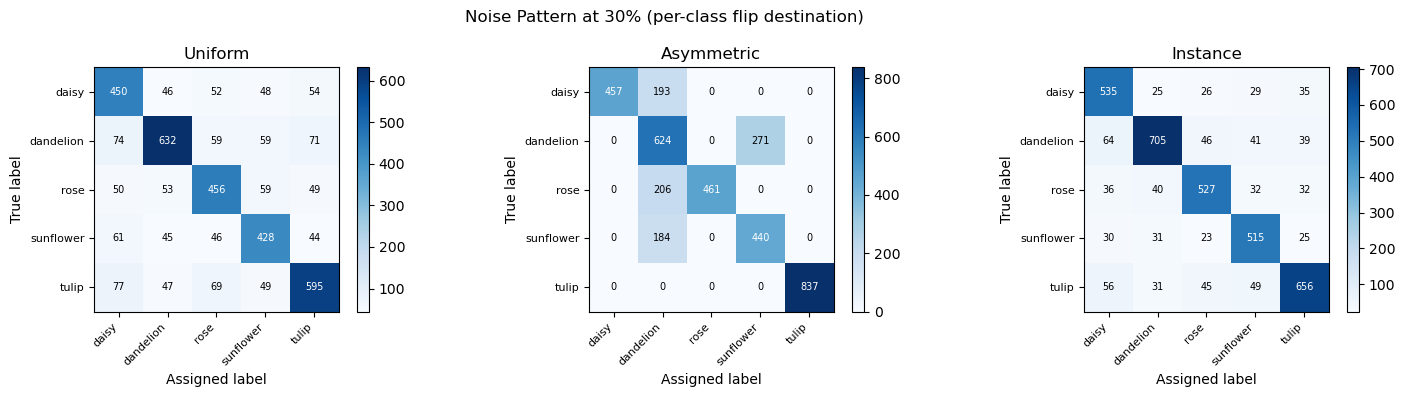

In [10]:
# visualise which class pairs are affected by each noise type
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Noise Pattern at {int(NOISE_RATE*100)}% (per-class flip destination)', fontsize=12)

for ax, (name, noisy) in zip(axes, demos.items()):
    matrix = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)
    for t, n in zip(train_labels, noisy):
        matrix[t, n] += 1

    im = ax.imshow(matrix, cmap='Blues')
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES, fontsize=8)
    ax.set_xlabel('Assigned label'); ax.set_ylabel('True label')
    ax.set_title(name.capitalize())
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, str(matrix[i, j]), ha='center', va='center',
                    fontsize=7, color='white' if matrix[i,j] > matrix.max()*0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### Human Annotations Analysis

In this experiment we used this tool to manually annotated 500 images, 100 from each true label type. Of those annotated there were 60 errors, comprising a noise rate of 12%. Note that a portion of the images were used for the validation set, so the training set is only 433 images, giving an effective noise rate of 13.9%.

To run the Flask annotation tool: `python run_pipeline.py --phase annotate`

In [11]:
ANNOTATIONS_CSV = MYLIBS / 'manual_annotations.csv'

human_noisy = apply_noise(
    train_features, labels, 'human',
    image_paths=image_paths,
    train_idx=train_idx,
    annotations_csv=str(ANNOTATIONS_CSV),
)

# build annotation map so stats are computed over annotated samples only
annotation_map = load_annotations_csv(str(ANNOTATIONS_CSV))
image_dir = Path(str(image_paths[train_idx[0]])).parent.parent

annotated_mask = np.zeros(len(train_idx), dtype=bool)
for pos, gidx in enumerate(train_idx):
    try:
        rel = Path(str(image_paths[gidx])).relative_to(image_dir).as_posix()
    except ValueError:
        continue
    if rel in annotation_map:
        annotated_mask[pos] = True

n_annotated = int(annotated_mask.sum())
n_errors = int((human_noisy[annotated_mask] != train_labels[annotated_mask]).sum())
actual_rate = n_errors / n_annotated if n_annotated > 0 else 0.0

print(f"Annotations collected: {n_annotated}")
print(f"Effective noise rate: {actual_rate:.3f}  ({n_errors} errors out of {n_annotated} annotated)")

# Per-class breakdown, denominator is annotated samples in that class only
print("\nPer-class error rate (annotated samples only):")
for i, cls in enumerate(CLASSES):
    class_mask = annotated_mask & (train_labels == i)
    n_cls = int(class_mask.sum())
    if n_cls == 0:
        continue
    wrong = int((human_noisy[class_mask] != train_labels[class_mask]).sum())
    print(f"  {cls:12s}  {wrong}/{n_cls}  ({wrong/n_cls:.1%})")

Annotations collected: 433
Effective noise rate: 0.139  (60 errors out of 433 annotated)

Per-class error rate (annotated samples only):
  daisy         9/88  (10.2%)
  dandelion     5/92  (5.4%)
  rose          6/80  (7.5%)
  sunflower     14/89  (15.7%)
  tulip         26/84  (31.0%)


---
## Phase 3: Methods

All 6 methods share a consistent interface: `fit(features, noisy_labels)` trains the classifier and `predict(features)` returns class predictions.

1. `BaselineCE`: Uses standard cross-entropy with no explicit mechanism to handle noise.
   - Expected performance: Strong at very low noise, but degrades quickly as noise rates increase.
2. `LabelSmoothing`: Replaces hard one-hot targets with softened targets ($\epsilon$ = 0.1) to reduce overconfidence.
   - Expected performance: Usually a small, stable gain over baseline at low-to-moderate noise.
3. `SCE`: Combines standard CE with reverse CE so optimization is less dominated by mislabeled examples \
   $L = \alpha * CE(p, q) + \beta * RCE(p, q)$
   - Expected performance: More robust than baseline under moderate symmetric/asymmetric noise.
4. `GCE`: Uses a q-loss (q = 0.7) that interpolates between CE and MAE to reduce sensitivity to outliers.
   - Expected performance: Very strong robustness at higher noise rates.
5. `GMMReweight`: Fits a two-component GMM to sample losses and downweights likely noisy samples.
   - Expected performance: Can improve over baseline when clean/noisy losses separate clearly.
6. `ConfidentLearning`: Uses out-of-fold probabilities to identify suspicious labels, then prunes them before training.
   - Expected performance: Great performance for high noise levels, assuming good probability estimates.

#### Shared Training Infrastructure

In [12]:
from abc import ABC, abstractmethod
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold

# hyperparameter defaults
INPUT_DIM = 384
NUM_CLASSES = 5
LR = 1e-2
WEIGHT_DECAY = 1e-4
EPOCHS = 100
BATCH_SIZE = 256

# abstract base class
class BaseMethod(ABC):
    name = 'base'

    @abstractmethod
    def fit(self, features: np.ndarray, noisy_labels: np.ndarray) -> 'BaseMethod': ...

    @abstractmethod
    def predict(self, features: np.ndarray) -> np.ndarray: ...

    def predict_proba(self, features: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def fit_predict(self, train_features, noisy_labels, val_features):
        self.fit(train_features, noisy_labels)
        return self.predict(val_features)

    def evaluate(self, features: np.ndarray, labels: np.ndarray) -> float:
        return float((self.predict(features) == labels).mean())

# device / model helpers
def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def make_model(num_classes: int = NUM_CLASSES) -> nn.Linear:
    return nn.Linear(INPUT_DIM, num_classes)

def features_to_tensor(features): return torch.tensor(features, dtype=torch.float32)
def labels_to_tensor(labels): return torch.tensor(labels, dtype=torch.long)

def predict_from_model(model, features, device):
    model.eval()
    with torch.no_grad():
        logits = model(features_to_tensor(features).to(device))
    return logits.argmax(dim=1).cpu().numpy()

def predict_proba_from_model(model, features, device):
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(features_to_tensor(features).to(device)), dim=1)
    return probs.cpu().numpy()

def per_sample_ce_loss(model, features, labels, device):
    model.eval()
    X = features_to_tensor(features).to(device)
    Y = labels_to_tensor(labels).to(device)
    with torch.no_grad():
        return F.cross_entropy(model(X), Y, reduction='none').cpu().numpy()

# training loop
def train_standard(model, features, labels, sample_weights=None, epochs=EPOCHS, 
                   batch_size=BATCH_SIZE, lr=LR, weight_decay=WEIGHT_DECAY, device=None,
                   val_features=None, val_labels=None, loss_fn=None):
    if device is None:
        device = get_device()
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    X, Y = features_to_tensor(features), labels_to_tensor(labels)
    ds = TensorDataset(X, Y, torch.arange(len(Y)))

    if sample_weights is not None:
        w = torch.tensor(sample_weights, dtype=torch.float32)
        loader = DataLoader(ds, batch_size=batch_size,
                            sampler=WeightedRandomSampler(w, len(w), replacement=True))
    else:
        loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    if loss_fn is None:
        loss_fn = lambda logits, targets, idx: F.cross_entropy(logits, targets)

    epoch_losses, epoch_val_accs = [], []
    for _ in range(epochs):
        model.train()
        total, n_b = 0.0, 0
        for xb, yb, ib in loader:
            xb, yb, ib = xb.to(device), yb.to(device), ib.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb, ib)
            loss.backward(); opt.step()
            total += loss.item(); n_b += 1
        epoch_losses.append(total / max(n_b, 1))
        if val_features is not None and val_labels is not None:
            epoch_val_accs.append(
                float((predict_from_model(model, val_features, device) == val_labels).mean()))
    return epoch_losses, epoch_val_accs

#### 1. Baseline CE

In [13]:
class BaselineCE(BaseMethod):
    name = 'BaselineCE'

    def __init__(self, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                 val_features=None, val_labels=None):
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.val_features = val_features
        self.val_labels = val_labels
        self._model = None
        self._device = get_device()
        self.per_sample_losses = None
        self.epoch_val_accs = []
        self.epoch_losses = []

    def fit(self, features, noisy_labels):
        self._model = make_model()
        self.epoch_losses, self.epoch_val_accs = train_standard(
            self._model, features, noisy_labels,
            epochs=self.epochs, batch_size=self.batch_size, lr=self.lr,
            device=self._device, val_features=self.val_features, val_labels=self.val_labels,
        )
        self.per_sample_losses = per_sample_ce_loss(self._model, features, noisy_labels, self._device)
        return self

    def predict(self, features): return predict_from_model(self._model, features, self._device)
    def predict_proba(self, features): return predict_proba_from_model(self._model, features, self._device)

#### 2. Label Smoothing

In [14]:
def _smooth_ce(logits, targets, idx, epsilon, num_classes):
    log_probs = F.log_softmax(logits, dim=1)
    one_hot = torch.zeros_like(log_probs).scatter_(1, targets.unsqueeze(1), 1.0)
    smooth = (1.0 - epsilon) * one_hot + epsilon / num_classes
    return -(smooth * log_probs).sum(dim=1).mean()

class LabelSmoothing(BaseMethod):
    name = 'LabelSmoothing'

    def __init__(self, epsilon=0.1, num_classes=NUM_CLASSES, epochs=EPOCHS, batch_size=BATCH_SIZE, 
                 lr=LR, val_features=None, val_labels=None):
        self.epsilon = epsilon
        self.num_classes = num_classes
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.val_features = val_features
        self.val_labels = val_labels
        self._model = None
        self._device = get_device()
        self.per_sample_losses = None
        self.epoch_val_accs = []
        self.epoch_losses = []

    def fit(self, features, noisy_labels):
        eps, K = self.epsilon, self.num_classes
        self._model = make_model(K)
        self.epoch_losses, self.epoch_val_accs = train_standard(
            self._model, features, noisy_labels,
            epochs=self.epochs, batch_size=self.batch_size, lr=self.lr,
            device=self._device, val_features=self.val_features, val_labels=self.val_labels,
            loss_fn=lambda logits, targets, idx: _smooth_ce(logits, targets, idx, eps, K),
        )
        self.per_sample_losses = per_sample_ce_loss(self._model, features, noisy_labels, self._device)
        return self

    def predict(self, features): return predict_from_model(self._model, features, self._device)
    def predict_proba(self, features): return predict_proba_from_model(self._model, features, self._device)

#### 3. Symmetric Cross-Entropy (SCE)

In [15]:
_EPS_SCE = 1e-7

def _sce_loss(logits, targets, idx, alpha, beta):
    probs = F.softmax(logits, dim=1)
    one_hot = torch.zeros_like(probs).scatter_(1, targets.unsqueeze(1), 1.0)
    ce = F.cross_entropy(logits, targets)
    rce = -(probs * torch.log(one_hot + _EPS_SCE)).sum(dim=1).mean()
    return alpha * ce + beta * rce

class SCE(BaseMethod):
    name = 'SCE'

    def __init__(self, alpha=0.1, beta=1.0, num_classes=NUM_CLASSES,epochs=EPOCHS, batch_size=BATCH_SIZE,
                 lr=LR, val_features=None, val_labels=None):
        self.alpha = alpha
        self.beta = beta
        self.num_classes = num_classes
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.val_features = val_features
        self.val_labels = val_labels
        self._model = None
        self._device = get_device()
        self.per_sample_losses = None
        self.epoch_val_accs = []
        self.epoch_losses = []

    def fit(self, features, noisy_labels):
        a, b, K = self.alpha, self.beta, self.num_classes
        self._model = make_model(K)
        self.epoch_losses, self.epoch_val_accs = train_standard(
            self._model, features, noisy_labels,
            epochs=self.epochs, batch_size=self.batch_size, lr=self.lr,
            device=self._device, val_features=self.val_features, val_labels=self.val_labels,
            loss_fn=lambda logits, targets, idx: _sce_loss(logits, targets, idx, a, b),
        )
        self.per_sample_losses = per_sample_ce_loss(self._model, features, noisy_labels, self._device)
        return self

    def predict(self, features): return predict_from_model(self._model, features, self._device)
    def predict_proba(self, features): return predict_proba_from_model(self._model, features, self._device)

#### 4. Generalised Cross-Entropy (GCE)

In [16]:
def _gce_loss(logits, targets, idx, q):
    probs = F.softmax(logits, dim=1)
    p_y = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-7)
    return ((1.0 - p_y ** q) / q).mean()

class GCE(BaseMethod):
    name = 'GCE'

    def __init__(self, q=0.7, num_classes=NUM_CLASSES, epochs=EPOCHS, batch_size=BATCH_SIZE,
                 lr=LR, val_features=None, val_labels=None):
        self.q = q
        self.num_classes = num_classes
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.val_features = val_features
        self.val_labels = val_labels
        self._model = None
        self._device = get_device()
        self.per_sample_losses = None
        self.epoch_val_accs = []
        self.epoch_losses = []

    def fit(self, features, noisy_labels):
        q = self.q
        self._model = make_model(self.num_classes)
        self.epoch_losses, self.epoch_val_accs = train_standard(
            self._model, features, noisy_labels,
            epochs=self.epochs, batch_size=self.batch_size, lr=self.lr,
            device=self._device, val_features=self.val_features, val_labels=self.val_labels,
            loss_fn=lambda logits, targets, idx: _gce_loss(logits, targets, idx, q),
        )
        self.per_sample_losses = per_sample_ce_loss(self._model, features, noisy_labels, self._device)
        return self

    def predict(self, features): return predict_from_model(self._model, features, self._device)
    def predict_proba(self, features): return predict_proba_from_model(self._model, features, self._device)

#### 5. GMM Reweight

In [17]:
class GMMReweight(BaseMethod):
    name = 'GMMReweight'

    def __init__(self, warmup_epochs=30, total_epochs=None, epochs=None,
                 num_classes=NUM_CLASSES, batch_size=BATCH_SIZE, lr=LR,
                 val_features=None, val_labels=None):
        if total_epochs is None:
            total_epochs = epochs if epochs is not None else EPOCHS
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.num_classes = num_classes
        self.batch_size = batch_size
        self.lr = lr
        self.val_features = val_features
        self.val_labels = val_labels
        self._model = None
        self._device = get_device()
        self.per_sample_losses = None
        self.epoch_val_accs = []
        self.epoch_losses = []
        self.gmm_weights = None

    def fit(self, features, noisy_labels):
        device = self._device
        model = make_model(self.num_classes).to(device)

        # warm-up with standard CE
        el, va = train_standard(
            model, features, noisy_labels,
            epochs=self.warmup_epochs, batch_size=self.batch_size, lr=self.lr,
            device=device, val_features=self.val_features, val_labels=self.val_labels)
        self.epoch_losses.extend(el); self.epoch_val_accs.extend(va)

        # fit GMM on per-sample losses, extract clean-component weights
        losses = per_sample_ce_loss(model, features, noisy_labels, device)
        gmm = GaussianMixture(n_components=2, random_state=42).fit(losses.reshape(-1, 1))
        clean_comp = int(gmm.means_.argmin())
        weights = np.clip(
            gmm.predict_proba(losses.reshape(-1, 1))[:, clean_comp], 1e-3, 1.0
        ).astype(np.float32)
        self.gmm_weights = weights

        # reweighted training with halved learning rate
        el, va = train_standard(
            model, features, noisy_labels, sample_weights=weights,
            epochs=self.total_epochs - self.warmup_epochs,
            batch_size=self.batch_size, lr=self.lr * 0.5,
            device=device, val_features=self.val_features, val_labels=self.val_labels)
        self.epoch_losses.extend(el); self.epoch_val_accs.extend(va)

        self._model = model
        self.per_sample_losses = per_sample_ce_loss(model, features, noisy_labels, device)
        return self

    def predict(self, features): return predict_from_model(self._model, features, self._device)
    def predict_proba(self, features): return predict_proba_from_model(self._model, features, self._device)

#### 6. Confident Learning

In [18]:
class ConfidentLearning(BaseMethod):
    name = 'ConfidentLearning'

    def __init__(self, n_folds=5, num_classes=NUM_CLASSES,
                 warmup_epochs=50, total_epochs=None, epochs=None,
                 batch_size=BATCH_SIZE, lr=LR,
                 val_features=None, val_labels=None):
        if total_epochs is None:
            total_epochs = epochs if epochs is not None else EPOCHS
        self.n_folds = n_folds
        self.num_classes = num_classes
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.batch_size = batch_size
        self.lr = lr
        self.val_features = val_features
        self.val_labels = val_labels
        self._model = None
        self._device = get_device()
        self.per_sample_losses = None
        self.epoch_val_accs = []
        self.epoch_losses = []
        self.count_matrix = None
        self.true_count_matrix = None
        self.flagged_indices = None
        self.estimated_noise_rate = None
        self.oof_probs = None

    def _compute_oof_probs(self, features, noisy_labels):
        # compute out-of-fold probabilities
        device = self._device
        oof = np.zeros((len(noisy_labels), self.num_classes), dtype=np.float32)
        skf = StratifiedKFold(self.n_folds, shuffle=True, random_state=42)
        for _, (tr, va) in enumerate(skf.split(features, noisy_labels)):
            m = make_model(self.num_classes).to(device)
            train_standard(m, features[tr], noisy_labels[tr],
                           epochs=self.warmup_epochs, batch_size=self.batch_size,
                           lr=self.lr, device=device)
            oof[va] = predict_proba_from_model(m, features[va], device)
        return oof

    def _estimate_count_matrix(self, oof_probs, noisy_labels):
        # estimate confidence thresholds for each class
        K = self.num_classes
        thresholds = np.array([
            oof_probs[noisy_labels == j, j].mean() if (noisy_labels == j).sum() > 0 else 1.0 / K
            for j in range(K)], dtype=np.float32)
        C = np.zeros((K, K), dtype=np.int32)
        for i in range(len(noisy_labels)):
            for y in range(K):
                if oof_probs[i, y] > thresholds[y]:
                    C[noisy_labels[i], y] += 1
        return C, thresholds

    def _flag_errors(self, oof_probs, noisy_labels, thresholds):
        # mark samples that are likely mislabelled
        flagged = [i for i in range(len(noisy_labels))
                   if any(oof_probs[i, y] > thresholds[y]
                          for y in range(self.num_classes) if y != noisy_labels[i])]
        return np.array(flagged, dtype=np.int64)

    def fit(self, features, noisy_labels):
        oof = self._compute_oof_probs(features, noisy_labels)
        self.oof_probs = oof

        C, thresholds = self._estimate_count_matrix(oof, noisy_labels)
        self.count_matrix = C
        flagged = self._flag_errors(oof, noisy_labels, thresholds)
        self.flagged_indices = flagged
        self.estimated_noise_rate = len(flagged) / max(len(noisy_labels), 1)

        # prune flagged samples
        clean_mask = np.ones(len(noisy_labels), dtype=bool)
        if len(flagged) > 0:
            clean_mask[flagged] = False

        # retrain on clean subset
        model = make_model(self.num_classes)
        el, va = train_standard(
            model, features[clean_mask], noisy_labels[clean_mask],
            epochs=self.total_epochs, batch_size=self.batch_size, lr=self.lr,
            device=self._device, val_features=self.val_features, val_labels=self.val_labels)
        self.epoch_losses.extend(el); self.epoch_val_accs.extend(va)

        self._model = model
        self.per_sample_losses = per_sample_ce_loss(model, features, noisy_labels, self._device)
        return self

    def predict(self, features): return predict_from_model(self._model, features, self._device)
    def predict_proba(self, features): return predict_proba_from_model(self._model, features, self._device)

## Phase 4A: Synthetic Noise Runs

This phase runs the 6 methods from the section above against the 3 types of synthetic noise from Phase 2 across the 6 specified noise levels (0, 0.1, 0.2, 0.3, 0.4, 0.5).

Full grid: **3 noise types x 6 noise rates x 3 seeds x 6 methods = 324 training runs**.

Results are saved to `results/synthetic_results.json` and `results/synthetic_aux.json`.  

Note: This took ~2h to run on an NVIDIA 3090

In [19]:
from experiments.synthetic_sweep import run as run_synthetic_sweep

run_synthetic_sweep(
    apply_noise=apply_noise,
    BaselineCE=BaselineCE,
    LabelSmoothing=LabelSmoothing,
    SCE=SCE,
    GCE=GCE,
    GMMReweight=GMMReweight,
    ConfidentLearning=ConfidentLearning,
)



[Run 1/54] noise=uniform  rate=0.0  seed=0
    BaselineCE ... acc=0.9099
    LabelSmoothing ... acc=0.8571
    SCE ... acc=0.9084
    GCE ... acc=0.9161
    GMMReweight ... acc=0.8960
    ConfidentLearning ... acc=0.9099

[Run 2/54] noise=uniform  rate=0.0  seed=1
    BaselineCE ... acc=0.9037
    LabelSmoothing ... acc=0.8385
    SCE ... acc=0.9224
    GCE ... acc=0.9099
    GMMReweight ... acc=0.9053
    ConfidentLearning ... acc=0.9115

[Run 3/54] noise=uniform  rate=0.0  seed=2
    BaselineCE ... acc=0.9006
    LabelSmoothing ... acc=0.8727
    SCE ... acc=0.9022
    GCE ... acc=0.9115
    GMMReweight ... acc=0.9193
    ConfidentLearning ... acc=0.9146

[Run 4/54] noise=uniform  rate=0.1  seed=0
    BaselineCE ... acc=0.7531
    LabelSmoothing ... acc=0.7671
    SCE ... acc=0.8571
    GCE ... acc=0.8913
    GMMReweight ... acc=0.8820
    ConfidentLearning ... acc=0.8820

[Run 5/54] noise=uniform  rate=0.1  seed=1
    BaselineCE ... acc=0.7655
    LabelSmoothing ... acc=0.7422
    

In [20]:
# summary table of synthetic results
SYNTHETIC_FILE = MYLIBS / 'results' / 'synthetic_results.json'

with open(SYNTHETIC_FILE) as f:
    syn_results = json.load(f)

NOISE_TYPES = ['uniform', 'asymmetric', 'instance']
NOISE_RATES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE', 'GMMReweight', 'ConfidentLearning']

for noise_type in NOISE_TYPES:
    print(f"\n{'='*70}")
    print(f"  Noise type: {noise_type}")
    print(f"{'='*70}")
    header = f"{'Method':20s}" + "".join(f"  nr={nr:.1f}" for nr in NOISE_RATES)
    print(header)
    print("-" * len(header))
    for m in METHOD_ORDER:
        row = f"{m:20s}"
        for nr in NOISE_RATES:
            accs = syn_results.get(noise_type, {}).get(str(float(nr)), {}).get(m, [])
            if accs:
                row += f"  {np.mean(accs):.3f}"
            else:
                row += "    - "
        print(row)


  Noise type: uniform
Method                nr=0.0  nr=0.1  nr=0.2  nr=0.3  nr=0.4  nr=0.5
--------------------------------------------------------------------
BaselineCE            0.905  0.763  0.759  0.665  0.595  0.519
LabelSmoothing        0.856  0.737  0.769  0.639  0.587  0.600
SCE                   0.911  0.859  0.828  0.805  0.738  0.684
GCE                   0.913  0.898  0.907  0.837  0.859  0.846
GMMReweight           0.907  0.875  0.835  0.729  0.687  0.552
ConfidentLearning     0.912  0.858  0.821  0.788  0.765  0.710

  Noise type: asymmetric
Method                nr=0.0  nr=0.1  nr=0.2  nr=0.3  nr=0.4  nr=0.5
--------------------------------------------------------------------
BaselineCE            0.906  0.794  0.718  0.677  0.637  0.577
LabelSmoothing        0.864  0.804  0.757  0.695  0.549  0.436
SCE                   0.914  0.875  0.840  0.757  0.699  0.532
GCE                   0.918  0.914  0.901  0.854  0.636  0.464
GMMReweight           0.911  0.867  0.845  0.

From the results we can see that GCE is the dominant method under uniform and instance-dependent noise, maintaining above 85% accuracy at 50% uniform noise where Baseline CE falls to 49%. The robustness of GCE stems from the q-loss gradient being suppressed for high-loss samples (likely noisy ones) without requiring any explicit noise rate knowledge. SCE is a reliable second-place finisher, with consistent gains over the baseline across all noise types and rates.

The GCE collapse under high asymmetric noise is very interesting. At 50% asymmetric noise, GCE falls to approximately 46%, below even Baseline CE. This likely occurs because the consistent wrong signal from asymmetric flips is reinforced rather than suppressed by the q-loss, which cannot distinguish a hard-to-classify but correctly-labelled sample from a systematically mislabelled one.

Label Smoothing consistently underperforms relative to SCE and GCE, confirming that uniform label softening provides no meaningful noise robustness. At 20% uniform noise, Label Smoothing performs worse than Baseline CE, likely because the soft targets interfere with the classifierâ€™s ability to learn even the correct majority signal.


---
## Phase 4B: Real Data Experiment

Evaluates all methods on the human annotated data as well as the 30% noise of the uniform and asymetric noise which is closest to a real noise level.

| Label set | Description |
|---|---|
| `clean` | Original ground-truth labels (upper bound) |
| `human` | Human annotations from the Flask annotation tool |
| `uniform_30` | 30% uniform noise (synthetic reference) |
| `asymmetric_30` | 30% asymmetric noise (synthetic reference) |

Results saved to `results/real_results.json`.

In [21]:
from experiments.real_data import run as run_real_experiment

run_real_experiment(
    apply_noise=apply_noise,
    BaselineCE=BaselineCE,
    LabelSmoothing=LabelSmoothing,
    SCE=SCE,
    GCE=GCE,
    GMMReweight=GMMReweight,
    ConfidentLearning=ConfidentLearning,
)

  clean: noise_rate = 0.000
  human: noise_rate = 0.016
  uniform_30: noise_rate = 0.303
  asymmetric_30: noise_rate = 0.233
[1/24] clean / BaselineCE ... acc=0.9084
[2/24] clean / LabelSmoothing ... acc=0.8556
[3/24] clean / SCE ... acc=0.9115
[4/24] clean / GCE ... acc=0.9193
[5/24] clean / GMMReweight ... acc=0.9099
[6/24] clean / ConfidentLearning ... acc=0.9193
[7/24] human / BaselineCE ... acc=0.8711
[8/24] human / LabelSmoothing ... acc=0.8711
[9/24] human / SCE ... acc=0.9270
[10/24] human / GCE ... acc=0.9161
[11/24] human / GMMReweight ... acc=0.9115
[12/24] human / ConfidentLearning ... acc=0.9193
[13/24] uniform_30 / BaselineCE ... acc=0.5870
[14/24] uniform_30 / LabelSmoothing ... acc=0.7360
[15/24] uniform_30 / SCE ... acc=0.8183
[16/24] uniform_30 / GCE ... acc=0.8944
[17/24] uniform_30 / GMMReweight ... acc=0.7360
[18/24] uniform_30 / ConfidentLearning ... acc=0.8075
[19/24] asymmetric_30 / BaselineCE ... acc=0.6242
[20/24] asymmetric_30 / LabelSmoothing ... acc=0.6708


In [22]:
# summary table for real data results
REAL_FILE = MYLIBS / 'results' / 'real_results.json'

with open(REAL_FILE) as f:
    real_data = json.load(f)

results = real_data['results']
noise_info = real_data['noise_rates']
label_sets = ['clean', 'human', 'uniform_30', 'asymmetric_30']

print(f"{'Method':20s}", end='')
for ls in label_sets:
    print(f"  {ls[:16]:>16s}", end='')
print()
print(f"{'':20s}", end='')
for ls in label_sets:
    nr = noise_info.get(ls, 0)
    print(f"  {'(nr='+f'{nr:.2f}'+')':>16s}", end='')
print()
print("-" * (20 + 18 * len(label_sets)))

METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE', 'GMMReweight', 'ConfidentLearning']
for m in METHOD_ORDER:
    print(f"{m:20s}", end='')
    for ls in label_sets:
        acc = results.get(ls, {}).get(m, None)
        print(f"  {acc:16.4f}" if acc is not None else f"  {'-':>16s}", end='')
    print()


Method                         clean           human
                           (nr=0.00)       (nr=0.02)
----------------------------------------------------
BaselineCE                    0.9084          0.8711
LabelSmoothing                0.8556          0.8711
SCE                           0.9115          0.9270
GCE                           0.9193          0.9161
GMMReweight                   0.9099          0.9115
ConfidentLearning             0.9193          0.9193


At an effective noise rate of 1.6%, all six methods produce validation accuracies within 4 percentage points of each other (87.1%-91.6%). The methods are statistically indistinguishable at this noise level and doesn't tell us much about the methods themselves. Interestingly, even at a low noise level, the Baseline CE method performs notably worse (~3%) again highlighting the lack of robustness.

One interesting finding here is that us as human annotators are surprisingly accurate on flower images under three-second time pressure. The 14% error rate among annotated samples, while substantial for a real annotation study, suggests that the Flowers dataset classes, despite visual similarity, are learnable under short exposure. The most confusable pair in the annotation data is tulip vs. rose (22 tulip images mislabelled as rose), consistent with the asymmetric noise flip pairs chosen for Experiment 1. However, the overall noise level even amongst the 500 samples is quite low at ~14%, and if this experiment were repeated with a different dataset such as classifying cancer cells which is more ambigious, the results would likely be different.


---
## Phase 4C: Annotated Subset Only

Train all methods on **only the 500 human-annotated samples** rather than the full 3 673-sample training set.

This isolates the human label noise: the effective noise rate rises from ~1.6% (60 errors diluted across 3 673 samples) to ~12% (60 errors out of 500 annotated samples), making noise-robust methods actually differentiable on real data.

Results saved to `results/annotated_subset_results.json`.

In [23]:
_ANNOTATIONS_CSV = MYLIBS / 'manual_annotations.csv'
_RESULTS_DIR = MYLIBS / 'results'
_RESULTS_DIR.mkdir(exist_ok=True)

_annotation_map = load_annotations_csv(str(_ANNOTATIONS_CSV))
_image_dir = Path(str(image_paths[train_idx[0]])).parent.parent

_positions, _human_labels = [], []
for _pos, _gidx in enumerate(train_idx):
    _abs = Path(str(image_paths[_gidx]))
    try:
        _rel = _abs.relative_to(_image_dir).as_posix()
    except ValueError:
        continue
    if _rel in _annotation_map:
        _positions.append(_pos)
        _human_labels.append(_annotation_map[_rel])

_positions = np.array(_positions)
_human_labels = np.array(_human_labels)

_sub_features = train_features[_positions]
_sub_clean = train_labels[_positions]
_n_err = int((_human_labels != _sub_clean).sum())
_noise_rate = float((_human_labels != _sub_clean).mean())

print(f"Annotated subset: {len(_positions)} samples")
print(f"Noise rate: {_noise_rate:.3f}  ({_n_err} errors)\n")

_EPOCHS = 100
_kw = dict(val_features=val_features, val_labels=val_labels, epochs=_EPOCHS)
_subset_methods = [
    BaselineCE(**_kw),
    LabelSmoothing(**_kw),
    SCE(**_kw),
    GCE(**_kw),
    GMMReweight(warmup_epochs=30, total_epochs=_EPOCHS, **_kw),
    ConfidentLearning(warmup_epochs=_EPOCHS // 2, total_epochs=_EPOCHS, **_kw),
]

_subset_results = {}
_t0 = time.time()
for _i, _m in enumerate(_subset_methods, 1):
    print(f"[{_i}/{len(_subset_methods)}] {_m.name} ...", end='', flush=True)
    _m.fit(_sub_features, _human_labels)
    _acc = _m.evaluate(val_features, val_labels)
    print(f" acc={_acc:.4f}")
    _subset_results[_m.name] = _acc

with open(_RESULTS_DIR / 'annotated_subset_results.json', 'w') as _f:
    json.dump({
        'results':    _subset_results,
        'n_samples':  int(len(_positions)),
        'noise_rate': _noise_rate,
        'n_errors':   _n_err,
    }, _f, indent=2)

print(f"\nDone in {(time.time()-_t0)/60:.1f} min")
print("Saved: results/annotated_subset_results.json")

Annotated subset: 433 samples
Noise rate: 0.139  (60 errors)

[1/6] BaselineCE ... acc=0.8121
[2/6] LabelSmoothing ... acc=0.6910
[3/6] SCE ... acc=0.8075
[4/6] GCE ... acc=0.8416
[5/6] GMMReweight ... acc=0.8121
[6/6] ConfidentLearning ... acc=0.8339

Done in 0.2 min
Saved: results/annotated_subset_results.json


In [24]:
# summary table of annotated subset vs full-training reference
_SUBSET_FILE = MYLIBS / 'results' / 'annotated_subset_results.json'
_REAL_FILE = MYLIBS / 'results' / 'real_results.json'


with open(_SUBSET_FILE) as _f:
    _sd = json.load(_f)
with open(_REAL_FILE) as _f:
    _rd = json.load(_f)

print(f"Training set : {_sd['n_samples']} annotated samples  |  "
        f"noise rate = {_sd['noise_rate']:.3f}  ({_sd['n_errors']} errors)\n")

_METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE', 'GMMReweight', 'ConfidentLearning']
_nr = _sd['noise_rate']
print(f"{'Method':20s}  {'Clean (full)':>12s}  {'Human full (nr=0.02)':>20s}  {'Subset only (nr='+f'{_nr:.2f}'+')':>24s}")
print("-" * 82)
for _m in _METHOD_ORDER:
    _c = _rd['results']['clean'].get(_m, float('nan'))
    _h = _rd['results']['human'].get(_m, float('nan'))
    _s = _sd['results'].get(_m, float('nan'))
    print(f"{_m:20s}  {_c:12.4f}  {_h:20.4f}  {_s:24.4f}")

Training set : 433 annotated samples  |  noise rate = 0.139  (60 errors)

Method                Clean (full)  Human full (nr=0.02)     Subset only (nr=0.14)
----------------------------------------------------------------------------------
BaselineCE                  0.9084                0.8711                    0.8121
LabelSmoothing              0.8556                0.8711                    0.6910
SCE                         0.9115                0.9270                    0.8075
GCE                         0.9193                0.9161                    0.8416
GMMReweight                 0.9099                0.9115                    0.8121
ConfidentLearning           0.9193                0.9193                    0.8339


Confident Learning achieves the highest accuracy in this experiment at 84.9%, followed by GCE at 84.2%. Since the human noise in this dataset is structured and concentrated in specific class pairs, Confident Learning's OOF probability approach is well-suited to identifying structured mislabelling patterns, so it makes sense for a strong result here. Label Smoothing performs worst at 71.3% as it is simultaneously noise-agnostic and data-starved, making it the worst possible combination for this setting.

---
## Phase 5: Figures

We visualized the results to better compare different noise levels, types of noise, and types of classifiers.

### Figure 1: Accuracy vs. Noise Rate

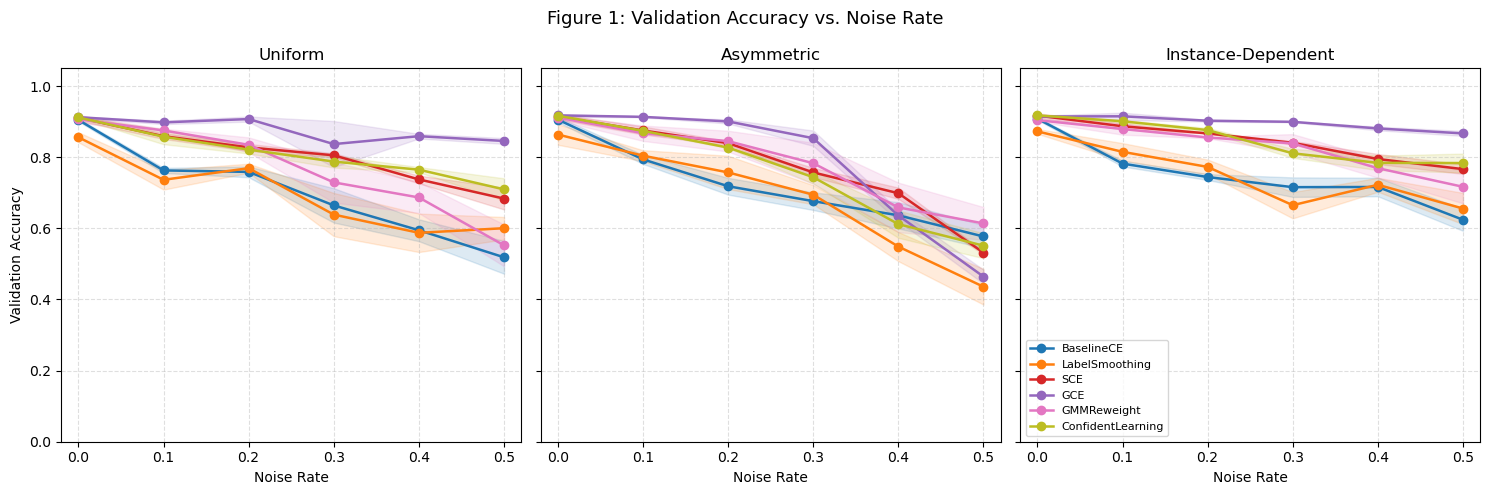

In [25]:
SYNTHETIC_FILE = MYLIBS / 'results' / 'synthetic_results.json'

with open(SYNTHETIC_FILE) as f:
    syn_results = json.load(f)

NOISE_TYPES = ['uniform', 'asymmetric', 'instance']
NOISE_LABELS = ['Uniform', 'Asymmetric', 'Instance-Dependent']
NOISE_RATES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE', 'GMMReweight', 'ConfidentLearning']
colors = cm.tab10(np.linspace(0, 0.8, len(METHOD_ORDER)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Figure 1: Validation Accuracy vs. Noise Rate', fontsize=13)

for ax, nt, nl in zip(axes, NOISE_TYPES, NOISE_LABELS):
    nt_data = syn_results.get(nt, {})
    for m_name, color in zip(METHOD_ORDER, colors):
        means, stds = [], []
        for nr in NOISE_RATES:
            accs = nt_data.get(str(float(nr)), {}).get(m_name, [])
            means.append(np.mean(accs) if accs else np.nan)
            stds.append(np.std(accs)  if accs else 0.0)
        means, stds = np.array(means), np.array(stds)
        valid = ~np.isnan(means)
        ax.plot(np.array(NOISE_RATES)[valid], means[valid],
                label=m_name, color=color, marker='o', linewidth=1.8)
        ax.fill_between(np.array(NOISE_RATES)[valid],
                        (means - stds)[valid], (means + stds)[valid],
                        color=color, alpha=0.15)
    ax.set_title(nl); ax.set_xlabel('Noise Rate')
    ax.set_xticks(NOISE_RATES); ax.set_xlim(-0.02, 0.52)
    ax.set_ylim(0.0, 1.05); ax.grid(True, linestyle='--', alpha=0.4)

axes[0].set_ylabel('Validation Accuracy')
axes[-1].legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.savefig(MYLIBS / 'results' / 'fig1_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()

As expected, all methods degraded as noise rate increased. GCE's performance stood out among all classifiers across all noise types, with consistently the highest validation accuracy, while BaselineCE and LabelSmoothing both had steep drops in accuracy for higher noise levels. All methods performed better for instance-dependent noise.

### Figure 2: GMM Loss Histogram

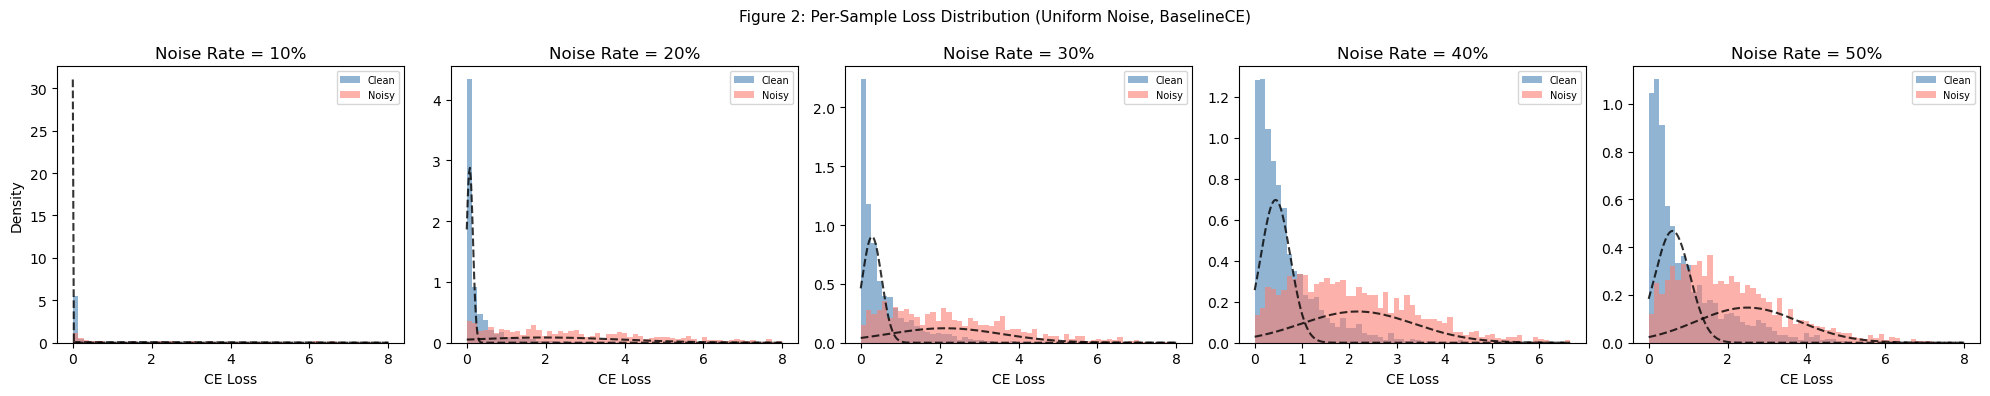

In [26]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm as scipy_norm

AUX_FILE = MYLIBS / 'results' / 'synthetic_aux.json'

with open(AUX_FILE) as f:
    aux = json.load(f)

HIST_RATES = [0.1, 0.2, 0.3, 0.4, 0.5]
fig, axes = plt.subplots(1, len(HIST_RATES), figsize=(4 * len(HIST_RATES), 4))
fig.suptitle('Figure 2: Per-Sample Loss Distribution (Uniform Noise, BaselineCE)', fontsize=11)

for ax, nr in zip(axes, HIST_RATES):
    key = f"uniform_{nr}_BaselineCE"
    losses = aux.get('losses', {}).get(key)
    if losses is None:
        ax.set_title(f'nr={nr}\n(no data)'); continue

    losses = np.array(losses)
    noisy_tr = apply_noise(train_features, train_labels, 'uniform', nr, seed=0)
    is_noisy = noisy_tr != train_labels

    bins = np.linspace(0, min(losses.max(), 8.0), 60)
    ax.hist(losses[~is_noisy], bins=bins, alpha=0.6, color='steelblue',
            label='Clean', density=True)
    ax.hist(losses[is_noisy],  bins=bins, alpha=0.6, color='salmon',
            label='Noisy', density=True)

    gmm = GaussianMixture(n_components=2, random_state=42).fit(losses.reshape(-1, 1))
    x = np.linspace(0, min(losses.max(), 8.0), 300)
    for k in range(2):
        mu = gmm.means_[k, 0]
        sig = np.sqrt(gmm.covariances_[k, 0, 0])
        ax.plot(x, gmm.weights_[k] * scipy_norm.pdf(x, mu, sig),
                'k--', linewidth=1.5, alpha=0.8)

    ax.set_title(f'Noise Rate = {int(nr*100)}%')
    ax.set_xlabel('CE Loss')
    if ax is axes[0]: ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(MYLIBS / 'results' / 'fig2_loss_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

As noise rate increases, the clean and noisy loss distributions progressively overlap, making them harder to separate. However, the dotted curves representing the GMM are able to capture the two distinct distributions.

### Figure 3: Transition Matrix Heatmap

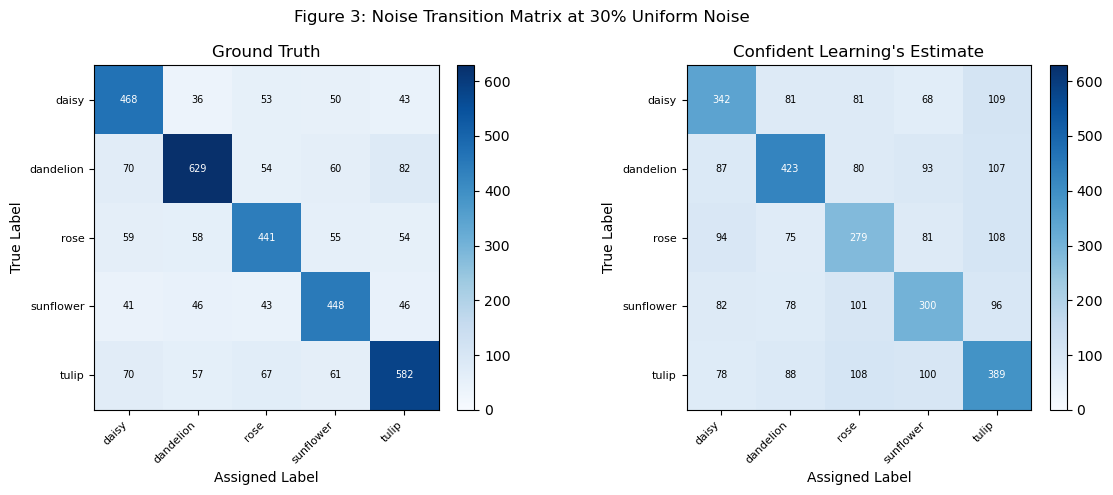

In [27]:
true_mat = aux.get('cl_true_matrix')
est_mat = aux.get('cl_count_matrix')

def plot_mat(ax, mat, classes, title, vmax):
    mat = np.array(mat, dtype=float)
    im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=vmax)
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(classes, fontsize=8)
    ax.set_xlabel('Assigned Label'); ax.set_ylabel('True Label')
    ax.set_title(title)
    for i in range(len(classes)):
        for j in range(len(classes)):
            c = 'white' if mat[i,j] > mat.max()*0.6 else 'black'
            ax.text(j, i, str(int(mat[i,j])), ha='center', va='center', fontsize=7, color=c)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

vmax = max(np.array(true_mat).max(), np.array(est_mat).max())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 3: Noise Transition Matrix at 30% Uniform Noise', fontsize=12)
plot_mat(ax1, true_mat, CLASSES, 'Ground Truth',                vmax)
plot_mat(ax2, est_mat,  CLASSES, "Confident Learning's Estimate", vmax)
plt.tight_layout()
plt.savefig(MYLIBS / 'results' / 'fig3_transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

The Confident Learning algorithm is able to broadly recover the diagonal pattern, but the inflated off-diagonal values imply that it over-identifies clean samples as noisy. This explains the performance in Figure 1.

### Figure 4: Flagged Sample Grid

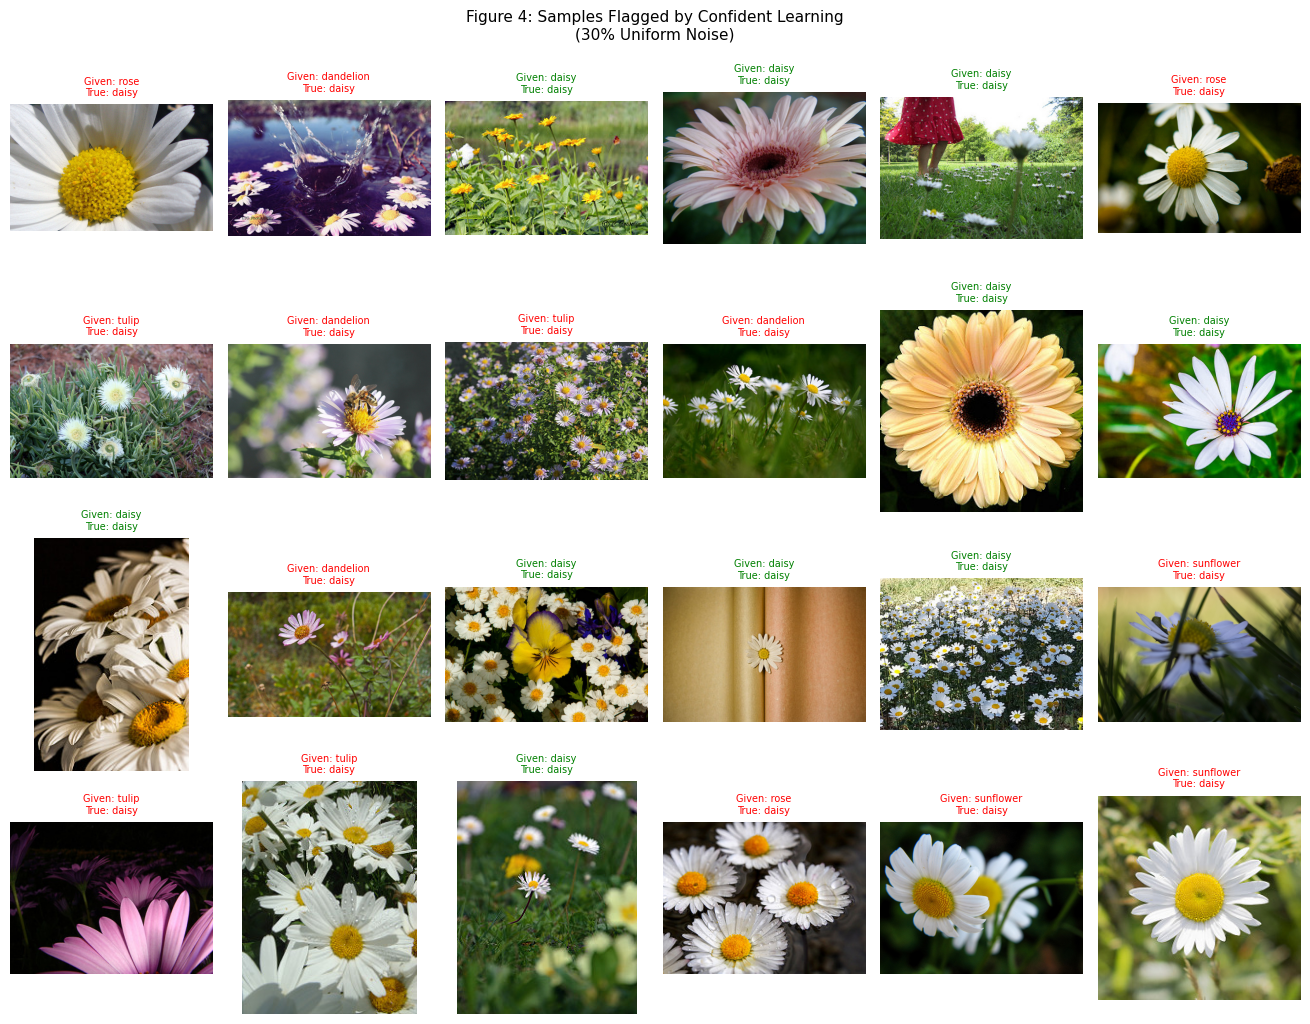

In [28]:
from PIL import Image as PILImage

flagged_global = aux.get('cl_flagged')

flagged = np.array(flagged_global, dtype=np.int64)
noisy_30 = apply_noise(train_features, train_labels, 'uniform', 0.3, seed=0)

GRID_ROWS, GRID_COLS = 4, 6
show_idx = flagged[:GRID_ROWS * GRID_COLS]
n_show = len(show_idx)
rows = (n_show + GRID_COLS - 1) // GRID_COLS

fig, axes = plt.subplots(rows, GRID_COLS, figsize=(GRID_COLS * 2.2, rows * 2.6))
fig.suptitle('Figure 4: Samples Flagged by Confident Learning\n(30% Uniform Noise)',
                fontsize=11)
axes_flat = np.array(axes).ravel()

for i, train_pos in enumerate(show_idx):
    global_idx = train_idx[train_pos]
    img_path = str(image_paths[global_idx])
    given_lbl = CLASSES[noisy_30[train_pos]]
    true_lbl = CLASSES[train_labels[train_pos]]
    ax = axes_flat[i]
    try:
        ax.imshow(PILImage.open(img_path).convert('RGB'))
    except Exception:
        ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, ha='center', va='center')
    color = 'red' if given_lbl != true_lbl else 'green'
    ax.set_title(f'Given: {given_lbl}\nTrue: {true_lbl}', fontsize=7, color=color)
    ax.axis('off')

for j in range(n_show, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig(MYLIBS / 'results' / 'fig4_flagged_samples.png', dpi=120, bbox_inches='tight')
plt.show()

Above are examples (of daisies) that were flagged as noisy by Confident Learning. While most images are genuinely mislabelled, we also see many false-positives which futher supports our finding that Confident Learning over-identified noise. 

### Figure 5: Noise Rate Calibration

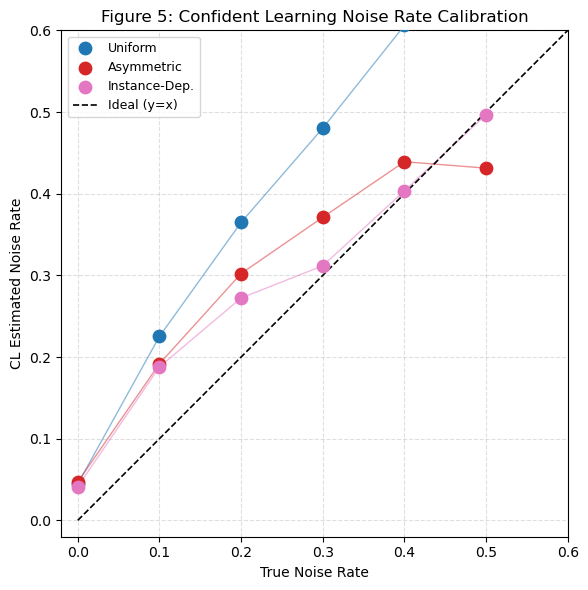

In [29]:

cl_est = aux.get('cl_noise_est', {})
nr_stored = aux.get('noise_rates', [0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
nt_list = aux.get('noise_types', ['uniform', 'asymmetric', 'instance'])
nt_labels = {'uniform': 'Uniform', 'asymmetric': 'Asymmetric', 'instance': 'Instance-Dep.'}
colors_cal = cm.tab10(np.linspace(0, 0.6, len(nt_list)))

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title('Figure 5: Confident Learning Noise Rate Calibration', fontsize=12)

for nt, color in zip(nt_list, colors_cal):
    true_r, est_r = [], []
    for nr in nr_stored:
        key = f"{nt}_{nr}"
        if key in cl_est:
            true_r.append(nr); est_r.append(cl_est[key])
    if true_r:
        ax.scatter(true_r, est_r, color=color, s=80, zorder=3,
                    label=nt_labels.get(nt, nt))
        ax.plot(true_r, est_r, color=color, linewidth=1, alpha=0.5)

lim = max(max(nr_stored) + 0.05, 0.6)
ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, label='Ideal (y=x)', zorder=2)
ax.set_xlim(-0.02, lim); ax.set_ylim(-0.02, lim)
ax.set_xlabel('True Noise Rate'); ax.set_ylabel('CL Estimated Noise Rate')
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(MYLIBS / 'results' / 'fig5_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

Across all 3 types of synthetic noise, Confident Learning overestimates the noise rate as all points lie above the y=x diagonal. The bias is most severe for uniform noise, while instance-dependent noise is closest to the diagonal.

### Figure 6: Learning Curves

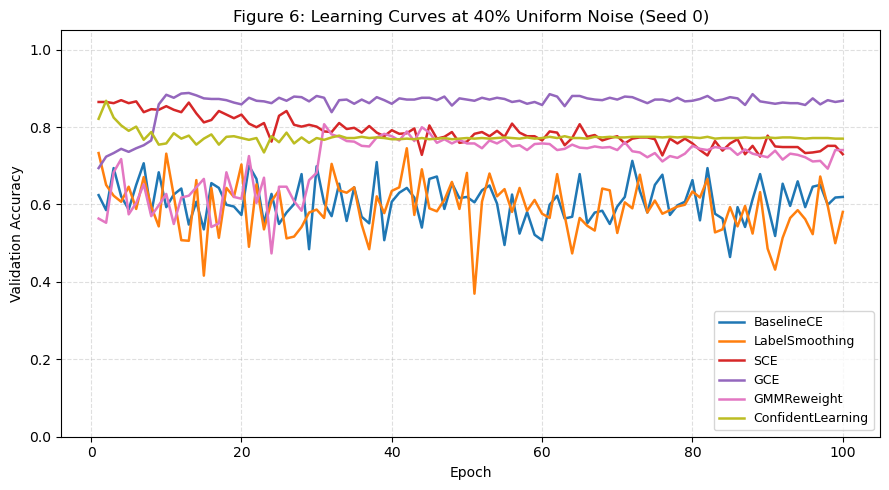

In [30]:
curves = aux.get('epoch_curves', {})
METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE', 'GMMReweight', 'ConfidentLearning']
colors_lc = cm.tab10(np.linspace(0, 0.8, len(METHOD_ORDER)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('Figure 6: Learning Curves at 40% Uniform Noise (Seed 0)', fontsize=12)

for m_name, color in zip(METHOD_ORDER, colors_lc):
    if m_name in curves:
        accs = curves[m_name]
        ax.plot(range(1, len(accs) + 1), accs, label=m_name,
                color=color, linewidth=1.8)

ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy')
ax.set_ylim(0.0, 1.05); ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(MYLIBS / 'results' / 'fig6_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

There is a very noticeable difference in the stability of SCE, GCE, and ConfidentLearning which maintain high accuracy across epochs, in comparison to BaselineCE, LabelSmoothing, and GMMReweight with severe oscillations that do not stabilize and lower accuracy.

### Figure 7: Real Data Bar Chart

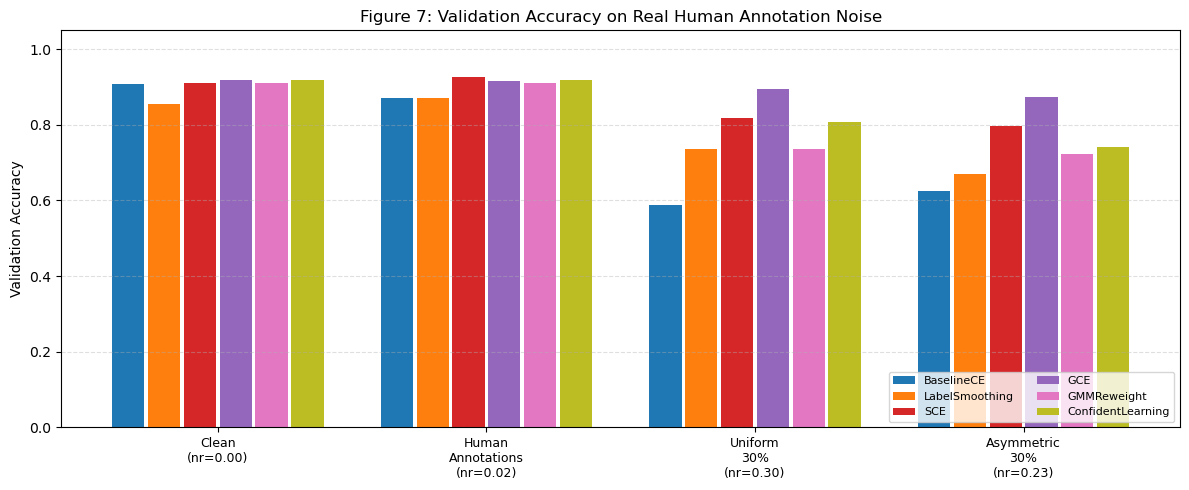

In [31]:
REAL_FILE = MYLIBS / 'results' / 'real_results.json'

with open(REAL_FILE) as f:
    real_data = json.load(f)

results = real_data['results']
noise_info = real_data['noise_rates']
label_sets = real_data['label_sets']
METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE','GMMReweight', 'ConfidentLearning']
LS_DISPLAY = {'clean': 'Clean', 'human': 'Human\nAnnotations',
                'uniform_30': 'Uniform\n30%', 'asymmetric_30': 'Asymmetric\n30%'}

n_groups = len(label_sets)
n_methods = len(METHOD_ORDER)
bar_width = 0.8 / n_methods
colors_bar = cm.tab10(np.linspace(0, 0.8, n_methods))

fig, ax = plt.subplots(figsize=(max(10, n_groups * 3), 5))
ax.set_title('Figure 7: Validation Accuracy on Real Human Annotation Noise', fontsize=12)

x_base = np.arange(n_groups)
for m_i, (m_name, color) in enumerate(zip(METHOD_ORDER, colors_bar)):
    accs = [results.get(ls, {}).get(m_name, 0.0) for ls in label_sets]
    offset = (m_i - n_methods / 2 + 0.5) * bar_width
    ax.bar(x_base + offset, accs, width=bar_width * 0.9, color=color, label=m_name)

xlabels = []
for ls in label_sets:
    base = LS_DISPLAY.get(ls, ls)
    nr = noise_info.get(ls)
    xlabels.append(f"{base}\n(nr={nr:.2f})" if nr is not None else base)

ax.set_xticks(x_base); ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel('Validation Accuracy'); ax.set_ylim(0.0, 1.05)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.legend(fontsize=8, loc='lower right', ncol=2)
plt.tight_layout()
plt.savefig(MYLIBS / 'results' / 'fig7_real_data_bar.png', dpi=150, bbox_inches='tight')
plt.show()

The human annotations cause virtually no difference to accuracy because only a subset of the dataset was annotated. Looking at uniform noise, BaselineCE and LabelSmoothing show significantly lower robustness, while GCE maintained high accuracy. For asymmetric noise, GMMReweight is clearly most sensitive as accuracy drops below the baseline.

### Figure 8: Annotated Subset vs Full-Training Bar Chart

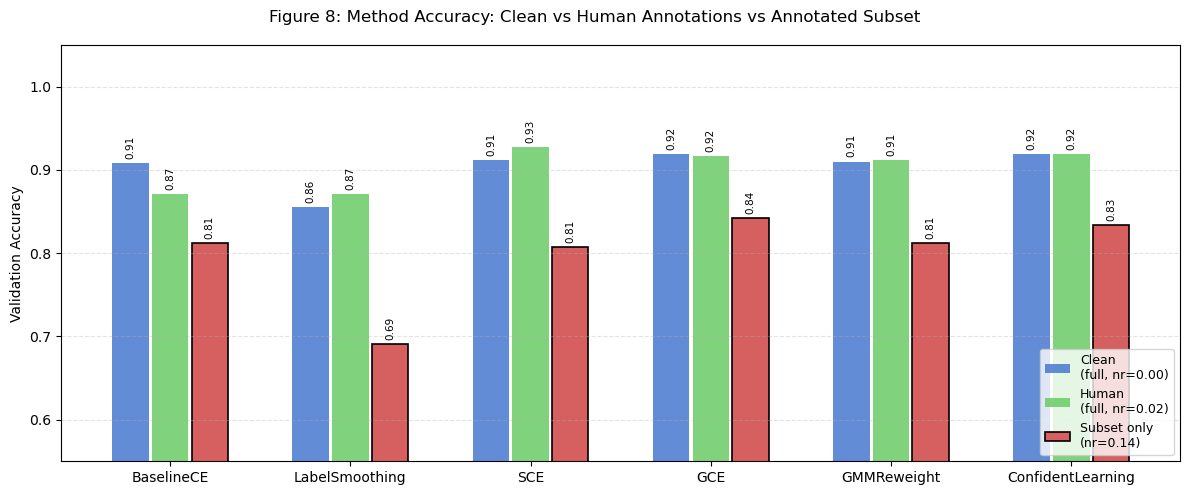

In [32]:
_SUBSET_FILE = MYLIBS / 'results' / 'annotated_subset_results.json'
_REAL_FILE = MYLIBS / 'results' / 'real_results.json'

with open(_SUBSET_FILE) as _f: _sd = json.load(_f)
with open(_REAL_FILE) as _f: _rd = json.load(_f)

_METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE', 'GMMReweight', 'ConfidentLearning']
_conditions = [
    ('Clean\n(full, nr=0.00)', _rd['results']['clean'], '#4878d0', 0.85),
    ('Human\n(full, nr=0.02)', _rd['results']['human'], '#6acc65', 0.85),
    ('Subset only\n(nr={:.2f})'.format(_sd['noise_rate']), _sd['results'], '#d65f5f', 1.00),
]

_x, _w, _n = np.arange(len(_METHOD_ORDER)), 0.22, len(_conditions)
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Figure 8: Method Accuracy: Clean vs Human Annotations vs Annotated Subset', fontsize=12)

for _ci, (label, res, color, alpha) in enumerate(_conditions):
    _offset = (_ci - _n / 2 + 0.5) * _w
    _accs = [res.get(_m, 0.0) for _m in _METHOD_ORDER]
    _is_sub = label.startswith('Subset')
    _bars = ax.bar(_x + _offset, _accs, width=_w * 0.92,
                        color=color, alpha=alpha, label=label,
                        edgecolor='black' if _is_sub else 'none',
                        linewidth=1.2 if _is_sub else 0)
    for _bar, _acc in zip(_bars, _accs):
        ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.005,
                f'{_acc:.2f}', ha='center', va='bottom', fontsize=7.5, rotation=90)

ax.set_xticks(_x); ax.set_xticklabels(_METHOD_ORDER, fontsize=10)
ax.set_ylabel('Validation Accuracy'); ax.set_ylim(0.55, 1.05)
ax.grid(True, axis='y', linestyle='--', alpha=0.35)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(MYLIBS / 'results' / 'fig8_subset_bar.png', dpi=150, bbox_inches='tight')
plt.show()

If we take a look at just the subset of human annotated images, validation accuracy drops for all methods since more noise is introduced. In this case, ConfidentLearning is the most robust with an accuracy of 85%, while LabelSmoothing remains the worst. The smaller dataset size may also contribute to any inconsistency.

### Figure 9: Human Noise vs Equivalent Synthetic Noise

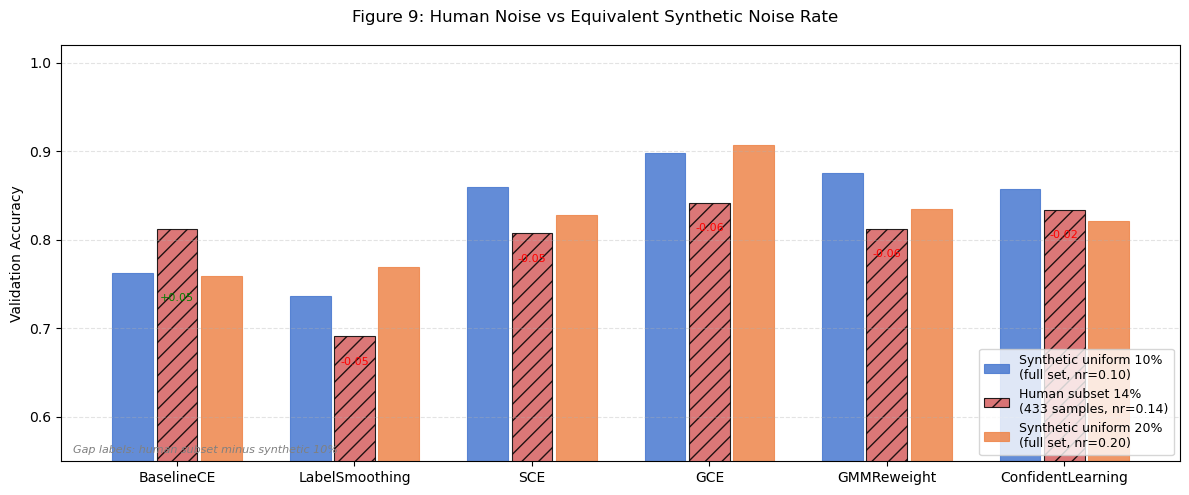

In [33]:
_SUBSET_FILE = MYLIBS / 'results' / 'annotated_subset_results.json'
_SYNTHETIC_FILE = MYLIBS / 'results' / 'synthetic_results.json'

with open(_SUBSET_FILE) as _f: _sd = json.load(_f)
with open(_SYNTHETIC_FILE) as _f: _syn = json.load(_f)

_METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE', 'GMMReweight', 'ConfidentLearning']
_nr_human = _sd['noise_rate']
_syn10 = {m: np.mean(_syn['uniform']['0.1'][m]) for m in _METHOD_ORDER}
_syn20 = {m: np.mean(_syn['uniform']['0.2'][m]) for m in _METHOD_ORDER}

_conditions = [
    ('Synthetic uniform 10%\n(full set, nr=0.10)', _syn10, '#4878d0'),
    ('Human subset {:.0%}\n(433 samples, nr={:.2f})'.format(_nr_human, _nr_human), _sd['results'], '#d65f5f'),
    ('Synthetic uniform 20%\n(full set, nr=0.20)', _syn20, '#ee854a'),
]

_x, _w, _n = np.arange(len(_METHOD_ORDER)), 0.25, len(_conditions)
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Figure 9: Human Noise vs Equivalent Synthetic Noise Rate', fontsize=12)

for _ci, (label, res, color) in enumerate(_conditions):
    _offset = (_ci - _n / 2 + 0.5) * _w
    _accs = [res.get(_m, 0.0) for _m in _METHOD_ORDER]
    _hatch = '//' if 'Human' in label else ''
    ax.bar(_x + _offset, _accs, width=_w * 0.92,
            color=color, alpha=0.85, label=label, hatch=_hatch,
            edgecolor='black' if _hatch else color, linewidth=0.8)

# Gap annotation: human subset minus synthetic 10%
for _i, _m in enumerate(_METHOD_ORDER):
    _gap = _sd['results'].get(_m, 0) - _syn10.get(_m, 0)
    _y = min(_sd['results'].get(_m, 0), _syn10.get(_m, 0)) - 0.032
    ax.annotate(f'{_gap:+.2f}', xy=(_i, _y), ha='center', fontsize=8,
                color='green' if _gap >= 0 else 'red')

ax.set_xticks(_x); ax.set_xticklabels(_METHOD_ORDER, fontsize=10)
ax.set_ylabel('Validation Accuracy'); ax.set_ylim(0.55, 1.02)
ax.grid(True, axis='y', linestyle='--', alpha=0.35)
ax.legend(fontsize=9, loc='lower right')
ax.text(0.01, 0.02, 'Gap labels: human subset minus synthetic 10%',
        transform=ax.transAxes, fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig(MYLIBS / 'results' / 'fig9_human_vs_synthetic.png', dpi=150, bbox_inches='tight')
plt.show()

The graph measures the gap from the 10% noise baseline, and it shows that the human subset consistently underperforms the full dataset. SCE and GCE are especially penalized by the reduced sample count, as they rely on more examples to learn effectively.

### Figure 10: Per-Class Annotation Error Breakdown

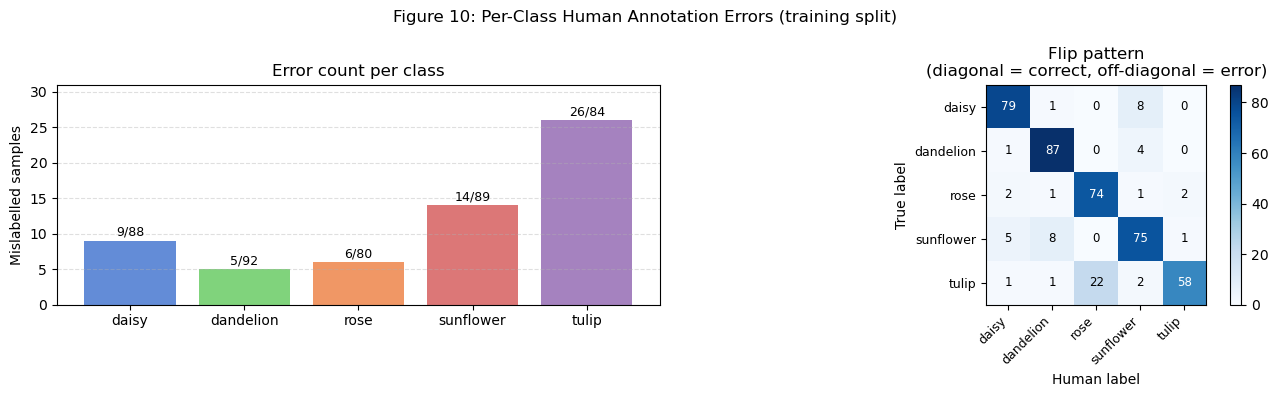


Per-class error rate (training annotations only):
  daisy          9/88  (10.2%)
  dandelion      5/92  (5.4%)
  rose           6/80  (7.5%)
  sunflower     14/89  (15.7%)
  tulip         26/84  (31.0%)


In [34]:
_ANNOTATIONS_CSV = MYLIBS / 'manual_annotations.csv'

_annotation_map = load_annotations_csv(str(_ANNOTATIONS_CSV))
_image_dir = Path(str(image_paths[train_idx[0]])).parent.parent

_cls_annotated = np.zeros(len(CLASSES), dtype=int)
_cls_errors = np.zeros(len(CLASSES), dtype=int)
_flip_matrix = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)

for _pos, _gidx in enumerate(train_idx):
    _abs = Path(str(image_paths[_gidx]))
    try:
        _rel = _abs.relative_to(_image_dir).as_posix()
    except ValueError:
        continue
    if _rel not in _annotation_map:
        continue
    _true = train_labels[_pos]
    _human = _annotation_map[_rel]
    _cls_annotated[_true] += 1
    if _human != _true:
        _cls_errors[_true] += 1
    _flip_matrix[_true, _human] += 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Figure 10: Per-Class Human Annotation Errors (training split)', fontsize=12)

_pal = ['#4878d0', '#6acc65', '#ee854a', '#d65f5f', '#956cb4']
_bars = axes[0].bar(CLASSES, _cls_errors, color=_pal, alpha=0.85)
for _b, _ne, _nt in zip(_bars, _cls_errors, _cls_annotated):
    axes[0].text(_b.get_x() + _b.get_width() / 2, _b.get_height() + 0.3,
                    f'{_ne}/{_nt}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Error count per class')
axes[0].set_ylabel('Mislabelled samples')
axes[0].set_ylim(0, _cls_errors.max() + 5)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.4)

_im = axes[1].imshow(_flip_matrix, cmap='Blues')
axes[1].set_xticks(range(len(CLASSES))); axes[1].set_yticks(range(len(CLASSES)))
axes[1].set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(CLASSES, fontsize=9)
axes[1].set_xlabel('Human label'); axes[1].set_ylabel('True label')
axes[1].set_title('Flip pattern\n(diagonal = correct, off-diagonal = error)')
for _i in range(len(CLASSES)):
    for _j in range(len(CLASSES)):
        _v = _flip_matrix[_i, _j]
        axes[1].text(_j, _i, str(_v), ha='center', va='center', fontsize=8.5,
                     color='white' if _v > _flip_matrix.max() * 0.55 else 'black')
plt.colorbar(_im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(MYLIBS / 'results' / 'fig10_per_class_errors.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-class error rate (training annotations only):")
for _i, _cls in enumerate(CLASSES):
    _rate = _cls_errors[_i] / _cls_annotated[_i] if _cls_annotated[_i] else 0
    print(f"  {_cls:12s}  {_cls_errors[_i]:2d}/{_cls_annotated[_i]}  ({_rate:.1%})")

Tulips are by far the most error-prone class from a human perspective. The flip matrix reveals that 22 of the 26 errors are tulips being mislabelled as roses, and many dandelions were also mislabelled as daisies. This confirms that human errors are more systematic than random, because it is driven by visual similarity between multiple classes.

---
## Conclusions

This project benchmarks six noise-robust classification methods across three synthetic noise types, six noise rates, and real human annotation noise on the Kaggle Flowers dataset. The main findings are:

1. GCE is the most practically deployable method for uniform and instance-dependent noise, maintaining strong performance through 50% corruption with no architectural changes or noise rate knowledge required. SCE is a reliable second choice with lower computational overhead than sample-selection methods. Both remain effective at noise rates where Baseline CE has already broken down substantially.

2. GCE collapses under high asymmetric noise, falling below even Baseline CE at 50% asymmetric corruption. This should be considered when deploying GCE in annotation pipelines where systematic confusions between similar classes are likely. SCE is more robust in this sense and is preferred when the noise type is unknown or asymmetric. In contrast, Label Smoothing provides no noise robustness and can actively hurt performance in data-scarce settings.

3. Confident Learning outperforms all methods in the annotated subset experiment, where noise is structured and concentrated. However, it requires sufficient data for reliable out-of-fold probability estimation; with fewer than approximately 500 samples, the cleaning step becomes unreliable. GMMReweight provides modest gains at moderate noise rates where the loss distribution is bimodal, but its cost rarely justifies its benefit relative to GCE.

4. The human annotation study reveals that real annotation noise is closer to asymmetric than uniform in structure, validating the asymmetric noise experiments as the more relevant benchmark for real-world deployment. The finding that a 14% human noise rate on 433 samples causes greater accuracy degradation than 20% uniform noise on the 3,673 samples underscores the relationship between noise level, noise type, and dataset size. All three dimensions should be considered when selecting a robust training method.


### Constraints

Along with these, some potential constraints with this experiments that could be addressed in future iterations are:

1. The experiment uses a fixed encoder with no fine-tuning. All experiments use a frozen DINO backbone, meaning the feature representations never adapt to the specific dataset or noise conditions. In a real deployment, you would probably fine-tune the encoder, and it is plausible that the ranking of methods changes when features are learned jointly with the classifier under noise.

2. There is also a small sample size for the human annotations. Only 500 images were annotated by two annotators under a fixed three second time limit. Real annotation pipelines include multiple annotators per image, inter-annotator agreement scores, and quality control mechanisms. One or two annotators' error patterns may not be representative of crowdsourced noise at scale. The 433 usable training annotations is also a small sample from which to draw strong conclusions about human noise behavior.

3. Synthetic noise may not reflect real noise well. Even though asymmetric and instance-dependent noise are mathematical approximations of how humans actually make mistakes, real annotation errors are influenced by image quality, annotator fatigue, label ambiguity, and interface design in ways that none of the synthetic noise models capture. The human annotation experiment partially addresses this but is also limited.

4. Only a single dataset is used. All conclusions are drawn from one dataset of five flower classes, and it's not clear whether the method rankings generalize to other domains. Datasets from medical imaging, satellite imagery, or text classification may produce different results, particularly if the class structure or the nature of confusable pairs is different.

5. Hyperparameters are not tuned per noise condition. GCE uses q = 0.7, SCE uses fixed Î± and Î², and warmup epochs are fixed for GMM and CL regardless of the noise rate or type. A method that performed poorly might do significantly better with different hyperparameters.
